# SPC convective and fire weather outlooks

The Storm Prediction Center's convective outlooks say, days ahead, where
severe thunderstorms are possible: categorical risks from general
thunderstorms through marginal, slight, enhanced, moderate, and high, and for
Day 1 and 2 the probability of a tornado, damaging wind, or large hail within
25 miles of a point. The Day 1 outlook is issued five times a day and revised
as the day unfolds. The Iowa Environmental Mesonet (IEM) archives every
outlook SPC has issued since 1987 and serves those issued in any window as a
zipped shapefile.

This walkthrough pulls every Day 1 convective outlook issued on 6 May 2024,
ahead of that evening's Oklahoma tornadoes, and follows how the forecast
changed through the day. It needs matplotlib, pandas, and pyshp, which reads
shapefiles, since usdata has no shapefile reader; the two files are a few
hundred kilobytes and the run takes a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import shapefile
from matplotlib.patches import PathPatch
from matplotlib.path import Path as Outline

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}; pyshp {shapefile.__version__}")

Executed (UTC): 2026-10-08T23:57:28+00:00
usdata 0.34.0; pandas 3.0.6; pyshp 3.1.6


## Select

Two sources over the same window, the UTC day of 6 May. The window selects by
when SPC **issued** an outlook, not the period it is valid for, which is what
a forecast made before a moment could have used. `days: 1` keeps the Day 1
outlooks. `geometry` chooses how risk areas nest: `cake_layer`, the default,
draws each risk level's whole area, so a place under a moderate risk is also
inside the slight and enhanced areas; `cookie_cutter` cuts each area to the
places where it is the highest risk. Outlooks are national, so there is no
location.

In [2]:
print(manifest.read_text())

name: spc-day1-outlooks-6-may-2024
sources:
  # Selected by when SPC issued them, not the period they are valid for.
  - name: layers
    dataset: noaa:spc-outlooks
    start: 2024-05-06T00:00Z
    end: 2024-05-06T23:59Z
    params: {days: 1}
  - name: cutters
    dataset: noaa:spc-outlooks
    start: 2024-05-06T00:00Z
    end: 2024-05-06T23:59Z
    params: {days: 1, geometry: cookie_cutter}



## What arrives

One zip per source and UTC month. IEM builds each on request and stamps it
with the time, so usdata rewrites it in a canonical form, stored uncompressed
with fixed stamps, which the lockfile can pin.

In [3]:
result = pull(manifest)
for name in ("layers", "cutters"):
    item = result.one(name)
    print(f"{name}: {item.path.name}, {item.provenance.size:,} bytes")
print("Source:", result.one("layers").provenance.source_url)
print("Transformations:", *result.one("layers").provenance.transformations, sep="\n  ")

layers: outlooks_20240506_20240506_8cc9b1125a71a563dfb9.zip, 62,300 bytes
cutters: outlooks_20240506_20240506_e0ec4b4db4865e2d325c.zip, 79,564 bytes
Source: https://mesonet.agron.iastate.edu/cgi-bin/request/gis/outlooks.py?type=C&geom=geom_layers&d=1&sts=2024-05-06T00%3A00%3A00Z&ets=2024-05-06T23%3A59%3A01Z
Transformations:
  iem canonical zip: members kept in order, stored uncompressed with timestamps fixed at 1980-01-01 00:00 and no extra fields; the DBF header's last-update date set to 1980-01-01


## Open

pyshp reads the zip; the helper below makes one row per outlook area and
parses the timestamps, which are `YYYYMMDDHHMM` text in UTC. `ISSUE` and
`EXPIRE` bound the period the outlook is valid for, `PRODISS` is when SPC
issued it, `THRESHOLD` and `CATEGORY` say what the area is, and `CYCLE` is
IEM's canonical issuance hour, `-1` for an issuance it superseded.

In [4]:
def read_zip(path: Path, times: list[str]) -> pd.DataFrame:
    """One row per shape: the DBF attributes, the named UTC times parsed, and the shape."""
    with shapefile.Reader(str(path)) as reader:
        names = [field[0] for field in reader.fields[1:]]
        frame = pd.DataFrame([list(record) for record in reader.records()], columns=names)
        frame["shape"] = reader.shapes()
    for column in times:
        frame[column] = pd.to_datetime(
            frame[column], format="%Y%m%d%H%M", utc=True, errors="coerce"
        )
    return frame


def patch(shape, **style) -> PathPatch | None:
    """A matplotlib patch for a polygon shape, its parts as rings so holes stay holes."""
    if not shape.points:
        return None
    vertices, codes = [], []
    for start, stop in zip(shape.parts, [*shape.parts[1:], len(shape.points)], strict=True):
        ring = shape.points[start:stop]
        vertices += ring
        codes += [Outline.MOVETO] + [Outline.LINETO] * (len(ring) - 1)
    return PathPatch(Outline(vertices, codes), **style)


TIMES = ["ISSUE", "EXPIRE", "PRODISS"]
layers = read_zip(result.one("layers").path, TIMES)
cutters = read_zip(result.one("cutters").path, TIMES)
issuances = layers.groupby("PRODISS").agg(
    cycle=("CYCLE", "first"),
    valid_from=("ISSUE", "first"),
    valid_to=("EXPIRE", "first"),
    areas=("CATEGORY", "size"),
)
issuances

,cycle,valid_from,valid_to,areas
PRODISS,,,,
2024-05-06 00:57:00+00:00,-1,2024-05-06 01:00:00+00:00,2024-05-06 12:00:00+00:00,4
2024-05-06 01:39:00+00:00,1,2024-05-06 01:00:00+00:00,2024-05-06 12:00:00+00:00,4
2024-05-06 05:55:00+00:00,6,2024-05-06 12:00:00+00:00,2024-05-07 12:00:00+00:00,19
2024-05-06 12:50:00+00:00,13,2024-05-06 13:00:00+00:00,2024-05-07 12:00:00+00:00,21
2024-05-06 16:02:00+00:00,16,2024-05-06 16:30:00+00:00,2024-05-07 12:00:00+00:00,22
2024-05-06 19:43:00+00:00,20,2024-05-06 20:00:00+00:00,2024-05-07 12:00:00+00:00,22


Six issuances. The first two are the previous evening's 01 UTC update,
valid until 12 UTC on the 6th: SPC issued it at 00:57 and again at 01:39, and
IEM keeps both, marking the earlier `-1`. The day's own outlooks follow at
05:55, 12:50, 16:02, and 19:43, each valid to 12 UTC on the 7th.

What was known before a moment is the latest outlook issued before it. At
02:12 UTC on 7 May, when the Barnsdall tornado began, that was the 20 UTC
outlook; a model trained to predict warnings should see that one and none
issued later.

In [5]:
moment = pd.Timestamp("2024-05-07T02:12Z")
known = layers[layers["PRODISS"] <= moment]
latest = known[known["PRODISS"] == known["PRODISS"].max()]
print(
    "Latest Day 1 outlook issued before", f"{moment:%Y-%m-%d %H:%M} UTC:", latest["PRODISS"].iloc[0]
)
latest.groupby("CATEGORY")["THRESHOLD"].agg(lambda values: ", ".join(values))

Latest Day 1 outlook issued before 2024-05-07 02:12 UTC: 2024-05-06 19:43:00+00:00


CATEGORY
CATEGORICAL      TSTM, MRGL, SLGT, ENH, MDT, HIGH
HAIL                 0.05, 0.15, 0.30, 0.45, SIGN
TORNADO        0.02, 0.05, 0.10, 0.15, 0.30, SIGN
WIND                 0.05, 0.15, 0.30, 0.45, SIGN
Name: THRESHOLD, dtype: str

## A first look

The categorical risk in each of the day's canonical Day 1 outlooks, drawn as
cookie cutters so each place shows its highest risk, in SPC's colors.

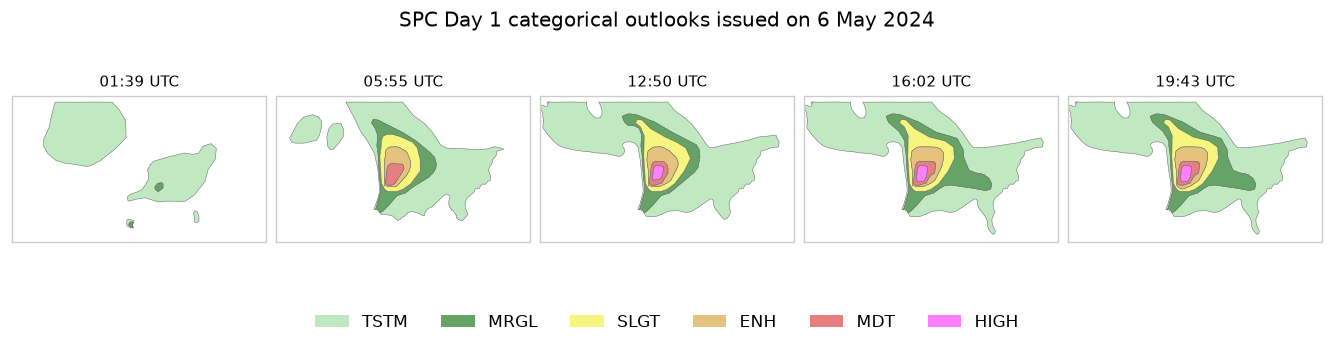

In [6]:
COLORS = {
    "TSTM": "#c1e9c1",
    "MRGL": "#66a366",
    "SLGT": "#f6f67f",
    "ENH": "#e6c27f",
    "MDT": "#e67f7f",
    "HIGH": "#ff80ff",
}
categorical = cutters[(cutters["CATEGORY"] == "CATEGORICAL") & (cutters["CYCLE"] >= 0)]
cycles = sorted(categorical["CYCLE"].unique())
fig, axes = plt.subplots(1, len(cycles), figsize=(11, 2.8), layout="constrained")
for ax, cycle in zip(axes, cycles, strict=True):
    outlook = categorical[categorical["CYCLE"] == cycle]
    for threshold, color in COLORS.items():
        for shape in outlook.loc[outlook["THRESHOLD"] == threshold, "shape"]:
            if (area := patch(shape, facecolor=color, edgecolor="0.4", linewidth=0.3)) is not None:
                ax.add_patch(area)
    ax.set_xlim(-125, -66)
    ax.set_ylim(24, 50)
    ax.set_aspect(1 / 0.77)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set(visible=True, color="0.8")
    ax.set_title(f"{outlook['PRODISS'].iloc[0]:%H:%M} UTC", fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color) for color in COLORS.values()]
fig.legend(handles, COLORS, loc="outside lower center", ncols=len(COLORS), frameon=False)
fig.suptitle("SPC Day 1 categorical outlooks issued on 6 May 2024")
plt.show()

SPC raised the risk through the morning: a moderate risk at 05:55, a high
risk from 12:50, kept through the 20 UTC outlook. The
tornado probabilities tell the same story in numbers: the highest in each
issuance, and whether a significant (EF2 or stronger) area was hatched.

In [7]:
tornado = layers[layers["CATEGORY"] == "TORNADO"]
numeric = tornado[tornado["THRESHOLD"] != "SIGN"].assign(
    probability=lambda frame: frame["THRESHOLD"].astype(float)
)
summary = numeric.groupby("PRODISS").agg(cycle=("CYCLE", "first"), highest=("probability", "max"))
summary["significant"] = tornado.groupby("PRODISS")["THRESHOLD"].apply(lambda t: "SIGN" in set(t))
summary

,cycle,highest,significant
PRODISS,,,
2024-05-06 00:57:00+00:00,-1,0.02,False
2024-05-06 01:39:00+00:00,1,0.02,False
2024-05-06 05:55:00+00:00,6,0.15,True
2024-05-06 12:50:00+00:00,13,0.30,True
2024-05-06 16:02:00+00:00,16,0.30,True
2024-05-06 19:43:00+00:00,20,0.30,True


## Pin and cite

`verify` checks the cached files against the lockfile's checksums. Keep the
manifest and lockfile with your analysis; the citation below is what a methods
section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:spc-outlooks
  NOAA/NWS Storm Prediction Center outlooks, as archived and served by the Iowa Environmental Mesonet of Iowa State University, accessed via usdata
  homepage: https://mesonet.agron.iastate.edu/request/gis/outlooks.phtml
  license: Public domain (NWS products; IEM materials are public domain, attribution appreciated)
  terms: https://mesonet.agron.iastate.edu/disclaimer.php
  retrieved: 2026-10-08; 2 checksummed assets (141,864 bytes) pinned by usdata 0.34.0
  sources: layers, cutters


## What was awkward

- There is no shapefile reader, so every notebook needs pyshp or geopandas
  and a helper like `read_zip` to get from the zip to a frame with times.
- Superseded issuances come back alongside the canonical ones; `CYCLE` tells
  them apart, but the rule IEM uses to pick one is, in its words, "not an
  exact science".
- `THRESHOLD` mixes risk labels, probabilities, and `SIGN` in one text column,
  so it has to be split by `CATEGORY` before any arithmetic.
- An outlook that drew no area is still a row with a null shape and an empty
  category, so drawing code has to skip empty shapes.
- There is no basemap: outlines of states would need another source.